<a href="https://colab.research.google.com/github/vijipandian/project/blob/main/Japan_Birth_Trends(1899_2023).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("/content/japan_birth_statistics_1899_2023.csv")
data.head(2)

,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate
0,2023,727288,372603,354685,6.0,105.1,1.20
1,2022,770759,395257,375502,6.3,105.3,1.26


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  122 non-null    int64  
 1   total_births          122 non-null    int64  
 2   male_births           122 non-null    int64  
 3   female_births         122 non-null    int64  
 4   crude_birth_rate      122 non-null    float64
 5   sex_ratio_at_birth    122 non-null    float64
 6   total_fertility_rate  77 non-null     float64
dtypes: float64(3), int64(4)
memory usage: 6.8 KB


In [4]:
data.isna().sum()

,0
year,0
total_births,0
male_births,0
female_births,0
crude_birth_rate,0
sex_ratio_at_birth,0
total_fertility_rate,45


In [5]:
data.nunique()

,0
year,122
total_births,122
male_births,122
female_births,122
crude_birth_rate,95
sex_ratio_at_birth,33
total_fertility_rate,54


In [6]:
list=["crude_birth_rate","sex_ratio_at_birth","total_fertility_rate"]
for col in list:
  data[col]=data[col].fillna(data[col].median())

In [7]:
data.isna().sum()

,0
year,0
total_births,0
male_births,0
female_births,0
crude_birth_rate,0
sex_ratio_at_birth,0
total_fertility_rate,0


In [8]:
data.describe()

,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate
count,122.000000,1.220000e+02,1.220000e+02,1.220000e+02,122.000000,122.000000,122.000000
mean,1961.393443,1.619319e+06,8.304865e+05,7.888323e+05,20.824590,105.310656,1.808852
std,36.585812,4.392864e+05,2.249261e+05,2.144170e+05,10.534323,0.858387,0.555854
min,1899.000000,7.272880e+05,3.726030e+05,3.546850e+05,6.000000,102.700000,1.200000
25%,1929.250000,1.212138e+06,6.233448e+05,5.887932e+05,9.825000,104.900000,1.500000
50%,1962.500000,1.656495e+06,8.494710e+05,8.058480e+05,18.600000,105.300000,1.720000
75%,1992.750000,1.985486e+06,1.014098e+06,9.673500e+05,32.375000,105.800000,1.800000
max,2023.000000,2.696638e+06,1.380008e+06,1.316630e+06,36.200000,108.700000,4.540000


**Visualization**

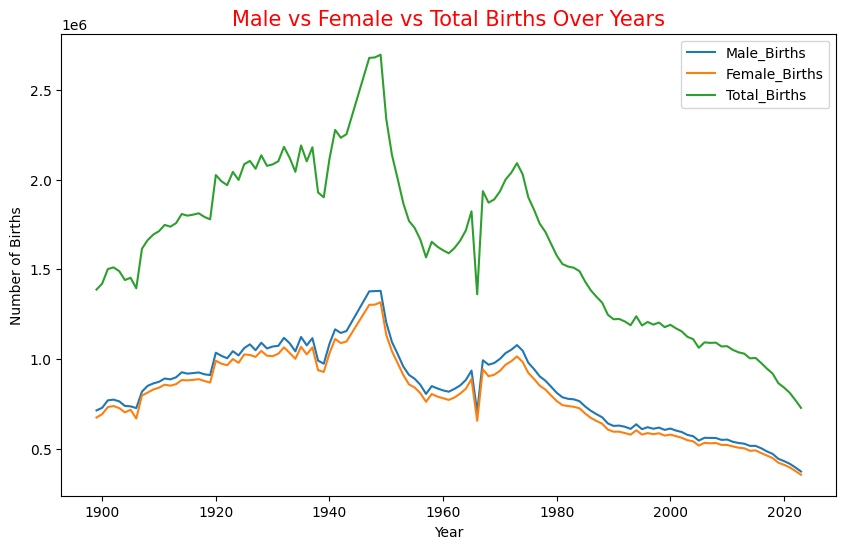

In [9]:
plt.figure(figsize=(10,6))
plt.plot(data['year'],data['male_births'])
plt.plot(data['year'],data['female_births'])
plt.plot(data['year'],data['total_births'])

plt.xlabel("Year")
plt.ylabel("Number of Births")
plt.title("Male vs Female vs Total Births Over Years",fontsize=15,color="red")
plt.legend(["Male_Births","Female_Births","Total_Births"])
plt.show()

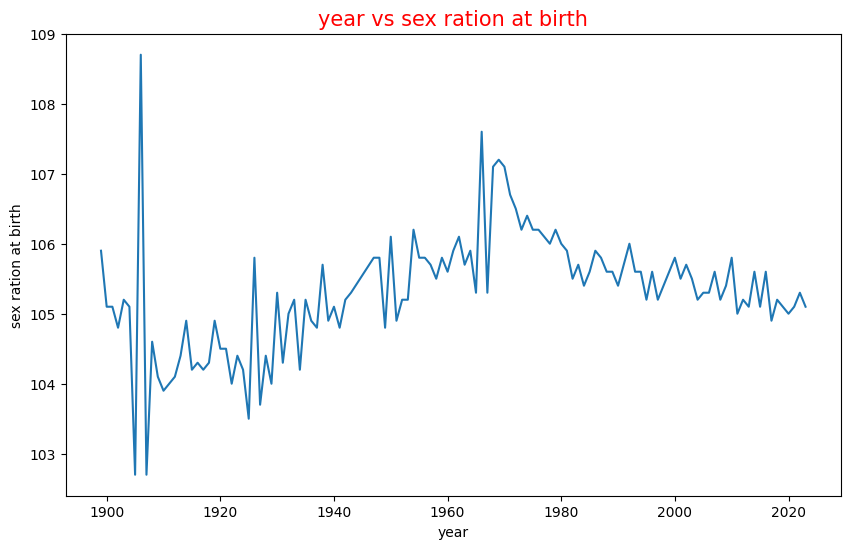

In [10]:
plt.figure(figsize=(10,6))
plt.plot(data['year'],data['sex_ratio_at_birth'])
plt.xlabel("year")
plt.ylabel("sex ration at birth")
plt.title("year vs sex ration at birth",fontsize=15,color="red")
plt.show()

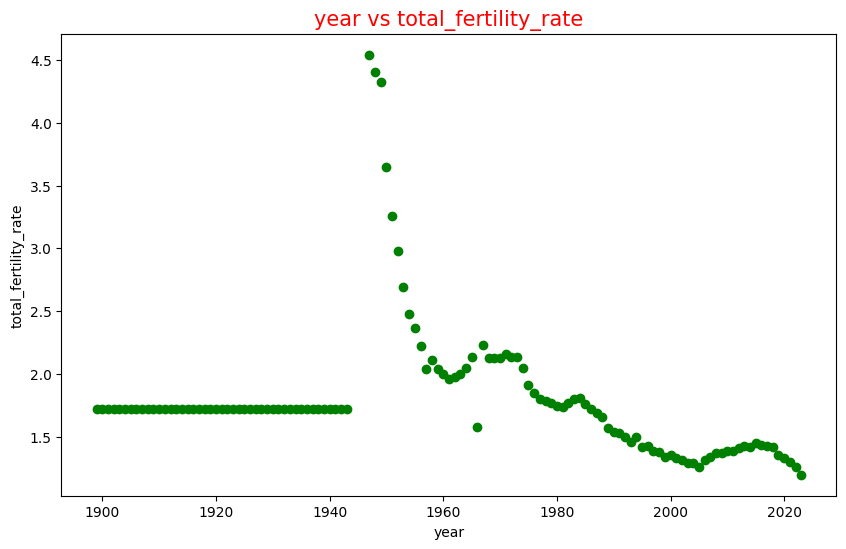

In [11]:
plt.figure(figsize=(10,6))
plt.scatter(data['year'],data['total_fertility_rate'],color="green")
plt.xlabel("year")
plt.ylabel("total_fertility_rate")
plt.title("year vs total_fertility_rate",fontsize=15,color="red")
plt.show()



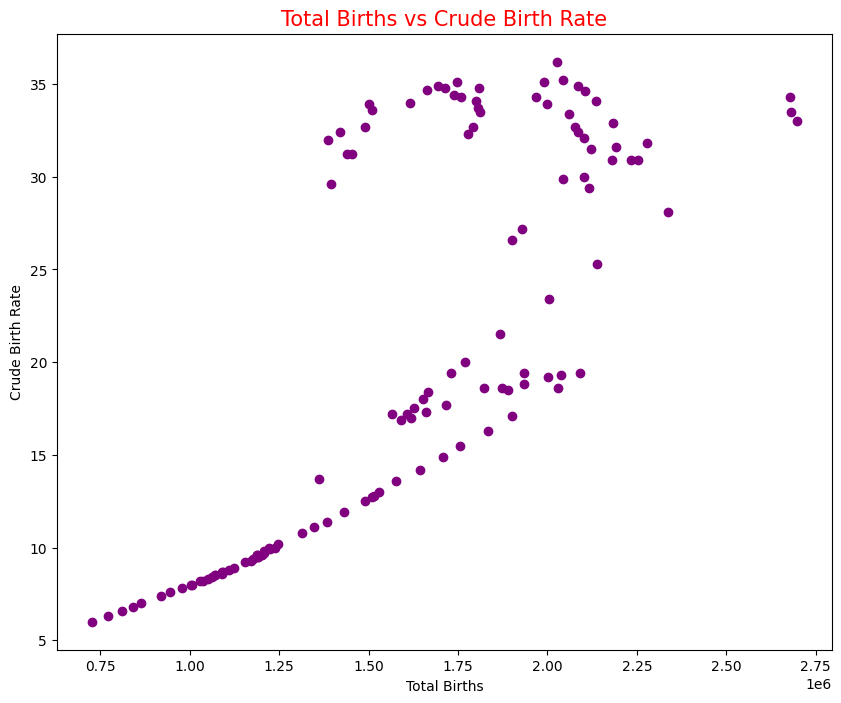

In [12]:
plt.figure(figsize=(10,8))
plt.scatter(data["total_births"],data['crude_birth_rate'],color="purple")
plt.xlabel("Total Births")
plt.ylabel("Crude Birth Rate")
plt.title("Total Births vs Crude Birth Rate",fontsize=15,color="red")
plt.show()

**ML**

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x=data[["year","crude_birth_rate", "sex_ratio_at_birth", "total_fertility_rate"]]
y=data['total_births']

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(97, 4)
(25, 4)
(97,)
(25,)


**LinearRegression**

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import  r2_score,mean_absolute_error

In [18]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [19]:
y_pred=model.predict(x_test)

In [20]:
print("mean absoulte error",mean_absolute_error(y_test,y_pred))
print("R2_score",r2_score(y_test,y_pred))

mean absoulte error 158787.19223805575
R2_score 0.8051937792491057


**RandomForest**

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score

In [22]:
model1=RandomForestRegressor()
model1.fit(x_train,y_train)

RandomForestRegressor()

In [23]:
y_pre=model1.predict(x_test)

In [24]:
print("mean absoulte error",mean_absolute_error(y_test,y_pre))
print("R2_score",r2_score(y_test,y_pre))

mean absoulte error 28676.81040000001
R2_score 0.9923656084820179


**DecisionTree**

In [25]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error,r2_score

In [26]:
dt=DecisionTreeRegressor(random_state=42)
dt.fit(x_train,y_train)

DecisionTreeRegressor(random_state=42)

In [27]:
y_pr=dt.predict(x_test)

In [28]:
print("mean absoulte error",mean_absolute_error(y_test,y_pr))
print("R2_score",r2_score(y_test,y_pr))

mean absoulte error 33463.76
R2_score 0.9901885041972941


**Models Comparison**

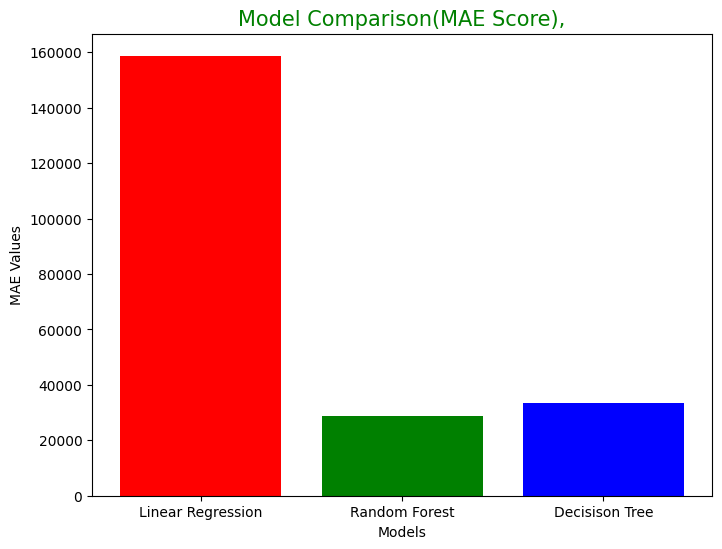

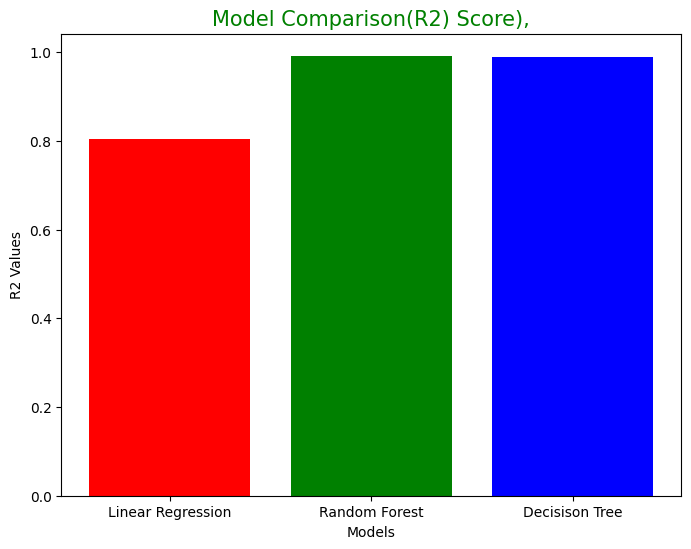

In [36]:
models=["Linear Regression","Random Forest","Decisison Tree"]
mae_values=[158787, 28676,33463]
r2_values=[0.8051,0.9923,0.9901]

plt.figure(figsize=(8,6))
plt.bar(models,mae_values,color=["red","green","blue"])
plt.xlabel("Models")
plt.ylabel("MAE Values")
plt.title("Model Comparison(MAE Score),",fontsize=15,color="green")
plt.show()



plt.figure(figsize=(8,6))
plt.bar(models,r2_values,color=["red","green","blue"])
plt.xlabel("Models")
plt.ylabel("R2 Values")
plt.title("Model Comparison(R2) Score),",fontsize=15,color="green")
plt.show()